## Base model for Students Outcome Predictor

### Description:
The Baseline Model is a Logistic Regression classifier. It is chosen for its simplicity, interpretability, and speed. In this project, the model's primary goal is to distinguish between students who will `Graduate` and those who will `Dropout`.

Priority Metric: Recall for the `Dropout` class, missing a student at risk (False Negative) is much more costly than accidentally flagging a successful student (False Positive). Therefore, I will evaluate the model primarily on its ability to capture as many true `dropouts` as possible.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


### 3.0 Load Data

The cleaned data was saved to `./data/processed/02.7_data_final.csv`. I will load this dataset for our modeling process.

In [43]:
df = pd.read_csv('../data/processed/02.7_data_final.csv')
df.head()

,marital_status,application_mode,application_order,course,daytime_evening,prev_qualification,prev_grade,nationality,mother_qualification,father_qualification,...,father_occupation_is_unknown,mother_occupation_is_unknown,father_qualification_is_unknown,mother_qualification_is_unknown,prev_qualification_is_unknown,any_info_missing,target_encoded,age_group,grade_progression,total_approved_units
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0,0,18-21,0.000000,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,0,0,0,0,2,18-21,-0.333333,12
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0,0,0,0,0,18-21,0.000000,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,0,0,0,0,2,18-21,-1.028571,11
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,0,0,0,0,2,31+,0.666667,11


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   marital_status                   4424 non-null   int64  
 1   application_mode                 4424 non-null   int64  
 2   application_order                4424 non-null   int64  
 3   course                           4424 non-null   int64  
 4   daytime_evening                  4424 non-null   int64  
 5   prev_qualification               4424 non-null   int64  
 6   prev_grade                       4424 non-null   float64
 7   nationality                      4424 non-null   int64  
 8   mother_qualification             4424 non-null   int64  
 9   father_qualification             4424 non-null   int64  
 10  mother_occupation                4424 non-null   int64  
 11  father_occupation                4424 non-null   int64  
 12  admission_grade     

***Interpretation:*** Imported data from the proccess data successfully, however, datatypes are not saved to the file. I will need to convert them to the appropriate types before modeling.

#### 3.1 Fix datatypes

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   marital_status                   4424 non-null   int64  
 1   application_mode                 4424 non-null   int64  
 2   application_order                4424 non-null   int64  
 3   course                           4424 non-null   int64  
 4   daytime_evening                  4424 non-null   int64  
 5   prev_qualification               4424 non-null   int64  
 6   prev_grade                       4424 non-null   float64
 7   nationality                      4424 non-null   int64  
 8   mother_qualification             4424 non-null   int64  
 9   father_qualification             4424 non-null   int64  
 10  mother_occupation                4424 non-null   int64  
 11  father_occupation                4424 non-null   int64  
 12  admission_grade     

##### 3.1.1 Fix binary columns datatypes

In [46]:
int_cols = ['displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international', 'daytime_evening', 'age_at_enrollment', 'cu1_credited', 'cu1_enrolled', 'cu1_evaluations', 'cu1_approved', 'cu1_no_evaluations', 'cu2_credited', 'cu2_enrolled', 'cu2_evaluations', 'cu2_approved', 'cu2_no_evaluations', 'total_approved_units']
df[int_cols] = df[int_cols].astype('int8')

# additional engineered features
unknown_flags = [
    'father_occupation_is_unknown', 'mother_occupation_is_unknown',
    'father_qualification_is_unknown', 'mother_qualification_is_unknown',
    'prev_qualification_is_unknown', 'any_info_missing'
]
df[unknown_flags] = df[unknown_flags].astype('int8')

# target variable
df['target_encoded'] = df['target_encoded'].astype('int8')


df[int_cols].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   displaced                4424 non-null   int8 
 1   special_needs            4424 non-null   int8 
 2   debtor                   4424 non-null   int8 
 3   tuition_fees_up_to_date  4424 non-null   int8 
 4   gender                   4424 non-null   int8 
 5   scholarship_holder       4424 non-null   int8 
 6   international            4424 non-null   int8 
 7   daytime_evening          4424 non-null   int8 
 8   age_at_enrollment        4424 non-null   int8 
 9   cu1_credited             4424 non-null   int8 
 10  cu1_enrolled             4424 non-null   int8 
 11  cu1_evaluations          4424 non-null   int8 
 12  cu1_approved             4424 non-null   int8 
 13  cu1_no_evaluations       4424 non-null   int8 
 14  cu2_credited             4424 non-null   int8 
 15  cu2_

****Interpretation:**** Binary and integer columns have been converted to int8 for memory efficiency. The memory usage has been reduced to `86.5KB` from `1.6+MB`


##### 3.1.2 Fix Category columns datatypes

In [47]:
categorical_cols = [
    'marital_status',
    'application_mode',
    'application_order',
    'course',
    'prev_qualification',
    'nationality',
    'mother_qualification',
    'father_qualification',
    'mother_occupation',
    'father_occupation'
]
df[categorical_cols] = df[categorical_cols].astype('category')

# new engineered feature as category
df['age_group'] = df['age_group'].astype('category')
df.info()

df[categorical_cols].info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   category
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

***Interpretation:*** All category columns were converted to category datatype, including the new features created during feature engineering in step 2.

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   category
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

*** Interpretation:*** All columns were updated to correct datatype, including the features that were created during the step feature engineerin in step 2.

### 3.2 Data Preparation: Remove Target Columns

In this step I will separate the features from the target columns. Also, I will filter out `Enrolled` students as these students will be used to deploy the model. So, the model will be trained using students with status `Graduate` or `Dropout`.

In [49]:
# create a copy excluding students with status Enrolled
df_baseline = df[df['target_encoded'] != 1].copy()

# define features and target
X = df_baseline.drop(['target', 'target_encoded'], axis=1)

# update the encoded values to mapping it to 0 and 1
# 0 = Dropout, 1 = Graduate to have a clean binary column.
y = df_baseline['target_encoded'].map({0:0, 2:1})


***Interpretation:*** Features and target were defined. Also, the target column was updated to a binary column with `0` for `Dropout` and `1` for `Graduate`.

In [50]:
X.shape, y.shape

((3630, 45), (3630,))

***Interpretation:*** The final dataset contains `3,630 rows`, `45 features`, and `1 target` variable.

### 3.3 Preprocessing and Pipeline

I will use ColumnTransformer to scale numeric features and encode categories. Then, create a pipeline for the base model.

In [51]:
# numerical features will be process with a StandardScaler
numeric_features = ['age_at_enrollment', 'cu1_grade', 'cu2_grade', 'total_approved_units', 'grade_progression']
# binary features
binary_features = ['debtor', 'tuition_fees_up_to_date', 'scholarship_holder', 'any_info_missing']
# Onehotencoder
categorical_features = ['age_group']


preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numeric_features),
    ('binary', 'passthrough', binary_features),
    ('categorical', OneHotEncoder(drop='first'), categorical_features)
])


# pipeline with LogisticRegression with a class_weight balance to hande the imbalance in Dropout vs Graduate
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

***Interpretation:*** A ColumnTransformer was created to encode numerical, binary, and categorical columns. The column transformer was passed to a pipeline with a LogisticRegression. The LogisticRegression was created with a params `class_weight=balanced` to handle the imbalance between `Graduate` and `Dropout`.

### 3.4 Training and Validation


In [52]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

#train model
baseline_pipeline.fit(X_train,y_train)

# evaluate prediction
y_pred = baseline_pipeline.predict(X_test)

print("Baseline Model: Logistic Regression")
print(classification_report(y_test, y_pred, target_names=['Dropout', 'Graduate']))


Baseline Model: Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.86      0.82      0.84       284
    Graduate       0.89      0.91      0.90       442

    accuracy                           0.88       726
   macro avg       0.88      0.87      0.87       726
weighted avg       0.88      0.88      0.88       726



***Interpretation:*** The `accuracy` of the base model was `0.88`, this means the model correctly predict the outcome for `88%` of the students in the test set. For a baseline model, this is a good accuracy, but we can try to improve it by tuning the hyperparameters or using more advanced models.

The `precision` was `0.86` for `Dropout` students, so the model succesfully identified `86%` of students who `Dropout`. This means that there is low `False Positive` with a `14%`.

The `F1-Score` is `0.84` which confirms the model is good identifying `Dropouts`

The `recall` which is the main metric to use in this project, was `0.82`, meaning that of all students who `Dropout` the model actually identified `82%` of them. The model is missing `18%` of `Dropouts`, I will try to improve the model to avoid missing potential dropout to allow advisor to help students on time before they dropout.



### 3.5 Confusion Matrix

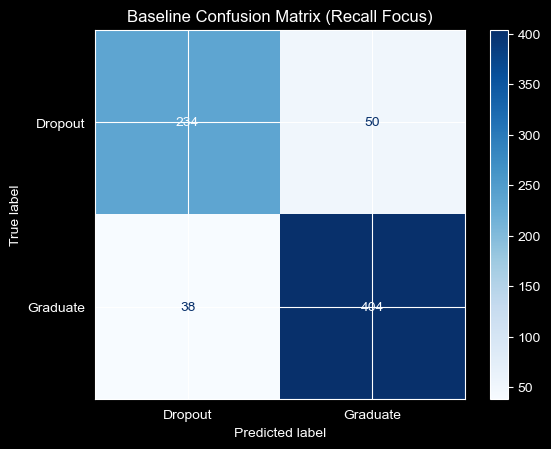

In [53]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['Dropout', 'Graduate'],
                                        cmap='Blues')
plt.title('Baseline Confusion Matrix (Recall Focus)')
plt.show()

***Interpretation:*** The total of `True Positive` was `234`, the model correctly caught `234` dropouts.

The amount of `True Negative` was `404`, this is the amount of students who `Graduate` and the model correctly identified them.

The amount of `False Positive` was `38`, meaning the model incorrectly identified `38` students who `Graduate` as `Dropout`. In this project, this value doesn't have importance because I prefer to flag a students as at risk of `Dropout` than missing a real student who is actually at risk.

The `False Negative` is `50`, meaning the model missed `50` students who `Dropout`, reducing this number is the goal when training better models. I want to improve the model to avoid missing potential dropout to allow advisor to help students on time before they dropout.

### 3.6 Baseline Model Review

The Logistic Regression has successfully established a performance baseline for predicting student outcomes.  By focusing on binary classification (Graduate vs. Dropout) and using a balanced class weight, I will try to improve the recall `82%`.